# Day 17: In-class Assignment: Modeling with Ordinary Differential Equations

### <p style="text-align: right;"> &#9989; Put your name here</p>

<img src="https://static1.squarespace.com/static/59e802b9be42d61a159cbf16/5adfb43d6d2a737eeb53231a/5adfb45870a6ad380a74f016/1524612324412/Photo+Apr+17%2C+6+23+00+PM+%281%29.jpg" width= 400><p style="text-align: right;">
</p>

### Goals for Today's In-Class Assignment
By the end of this assignment, you should be able to:
* Use functions to define derivatives that model the evolution of a physical system.
* Use loops to update the state of an evolving system.
* Use `solve_ivp` to model a physical system
* Use <code>matplotlib</code> to plot the evolution of the system.
* Use NumPy when necessary to manipulate arrays or perform mathematical operations
* Compare the differences between different numerical solutions to ODEs

### Assignment instructions

Today, **with your group**, you're going to try to apply what you've learned in the pre-class assignment to solve ODEs to model a physical system.

**This assignment is due at the end of class** and should be uploaded into the appropriate "In-class Assignments" submission folder.  Submission instructions can be found at the end of the notebook.

---
# Part 1: Modeling a falling skydiver without air resistance

In this assignment, we will be modeling the motion of a skydiver. There are two variables that will be changing that we need to consider:
- The *height* of the skydiver (I.e., how far above the ground they are). This value will change with time as the skydiver gets closer and closer to the ground during their fall. 
- The *speed* (or, really, the *velocity*) of the skydiver (I.e., how fast they are falling towards the ground). The longer the skydiver falls, the faster they will be falling. 

Since we have two values that are changing, we will need two differential equations. Without air resistance, these equations are

$$\frac{dh}{dt} = v$$

$$\frac{dv}{dt} = g$$

The main variables to know are: $h$ refers to height, and $v$ refers to velocity.  $g$ is acceleration due to gravity, and is a constant equal to $-9.81$. (Everything on Earth picks up speed at [roughly the same rate, as long as we ignore air resistance.](https://www.youtube.com/watch?v=frZ9dN_ATew))

---
## Part 1a: Solving the ODEs using update equations

For your first solution, you're going to model the motion of the skydiver **using loops and update equations**. Remember that update equations can be expressed as the following:

$$h_{\mathrm{new}} = h_{\mathrm{old}} + \frac{dh}{dt}\Delta t$$

$$v_{\mathrm{new}} = v_{\mathrm{old}} + \frac{dv}{dt}\Delta t$$

&#9989;&nbsp; **As a group**, write some pseudocode to implement a model (system of equations) that describes the motion of the skydiver.

You and your groups members are expected to **use your whiteboard for this.**. 

*Things to think about:*
- What are your key variables?  
- You should define a function to calculate the derivatives.  What will that function look like? 
- What steps will you need to take within your loop?


<font size="+3">&#9998;</font> _Put the pseudocode for your model here; Discuss your key variables; Basic equations; Steps to solve this problem_

---
&#9989;&nbsp; Once you have a plan, translate it into code. Again, you should *use loops and update equations* to solve the problem.  You should **make a plot of the height and the velocity as a function of time.**

The values you should use in your model are:
* $h_0 = 3000$ meters
* $v_0 = 0$ meters/second
* $g = -9.81$ gravity: meters/second^2
* $t_{max} = 30$ falling duration: seconds
* $dt = 1$ timestep

In [9]:
# Put your code here


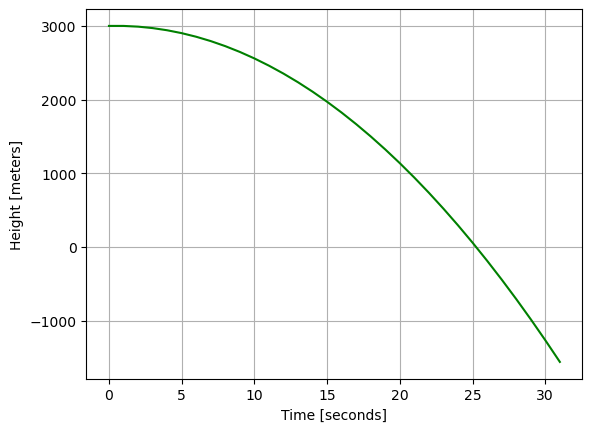

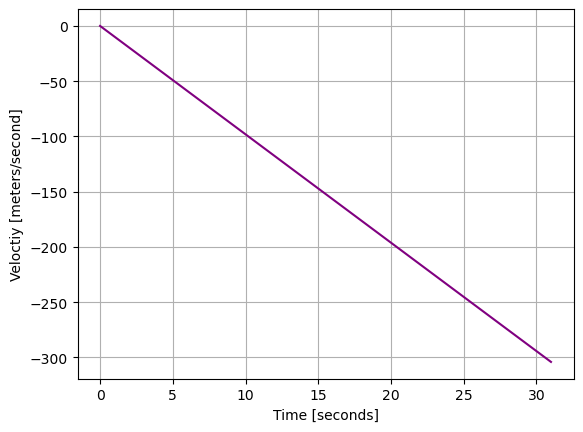

In [10]:
### ANSWER

# Import modules
import matplotlib.pyplot as plt

def derivs(v,g):

    dhdt = v
    dvdt = g
    
    return dhdt, dvdt

# Initialize variables
h = 3000 # initial height: m
v = 0 # initial velocoty: m/s 
g = -9.81 # gravity: m/s^2
t = 0 # initial time
tmax = 30 # Falling time
dt = 1 # timestep

# Initialize lists for storing data
height = []
velocity = []
time = []

# Append initial values to lists
height.append(h)
velocity.append(v)
time.append(t)

# Create a time loop that will update the skydiver over time
# Use a while loop that will loop until t > tmax
while t <= tmax:
    
    # Compute derivatives for use in update equations
    dhdt, dvdt = derivs(v,g)
    
    # Update Equations
    h_new = h + dhdt*dt # new height
    v_new = v + dvdt*dt # new velocity
    
    # Append values to height and velocity lists
    height.append(h_new)
    velocity.append(v_new)
    
    # Update old height/velocity with new height
    h = h_new
    v = v_new
    
    # Increase time
    t += dt # t = t + dt
    
    # Update time list
    time.append(t)
    
# Plotting height/velocity vs time 
plt.figure(1)
plt.plot(time, height, color = 'green')
plt.xlabel('Time [seconds]')
plt.ylabel('Height [meters]')
plt.grid()

plt.figure(2)
plt.plot(time, velocity, color = 'purple')
plt.xlabel('Time [seconds]')
plt.ylabel('Veloctiy [meters/second]')
plt.grid()

&#9989;&nbsp; **Question:** If you want the model to stop when the skydiver hits the ground (going far too fast at the moment!), how might you build that into the model?

<font size=+3>&#9998;</font> *Put your answer here.*

---
## Part 1b: Solving the ODEs with `solve_ivp`

Above, you performed numerical update equations to solve for length and velocity. For your second solution, you're going to model the motion of the bungee jumper using `solve_ivp`, a flexible python solution for these types of problems (systems modeled with 1st order differential equations).

The basic anatomy for the use of `solve_ivp` can be seen here:

<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/Day-14/solve_ivp_structure.png?raw=true" alt="solve-ivp-structure" border="0" width=1200>

&#9989;&nbsp; **Write some pseudocode to describe the model using `solve_ivp`.**  What will be different about this implementation in comparison with the update equations from above?

<font size="+3">&#9998;</font> _Put the pseudocode for your model here; Discuss your key variables; Basic equations; Steps to solve this problem_

**Then, write the actual code!**  Once you have a working model, you should again make a plots of the height and velocity as a function of time.

**Note**: You should be able to use what you figured out from the update equation solution to help guide your `solve_ivp` solution.


In [19]:
# Put your code here


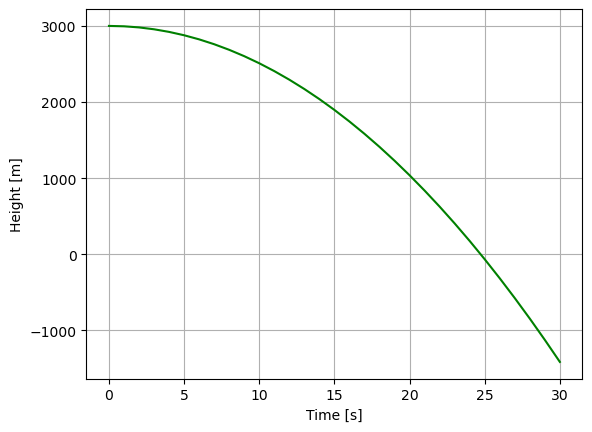

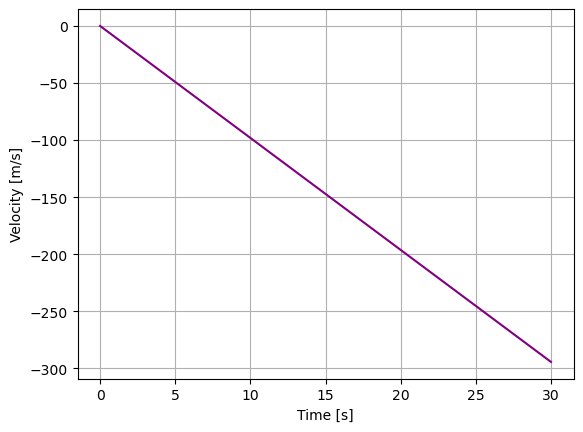

In [20]:
### ANSWER ###

import numpy as np
from scipy.integrate import solve_ivp

# Derivative function
def derivs(time,curr_vals):
    
    # Declare parameters
    g = -9.81 # m/s^2
    
    # Unpack the current values of the variables we wish to "update" from the curr_vals list
    h, v = curr_vals
    
    # Right-hand side of odes, which are used to computer the derivative
    dhdt = v
    dvdt = g
    
    return dhdt, dvdt

# Declare Variables for initial conditions
h0 = 3000 # meters
v0 = 0 # m/s
tmax = 30 # seconds
dt = 1 # seconds

# Define the time array
time = np.arange(0, tmax + dt, dt)

# Store the initial values in a list
init = [h0, v0]

# Solve the odes with solve_ivp
sol = solve_ivp(derivs,(0,tmax),init,t_eval = time)
    
# Plot the results using the values stored in the solution variable, "sol"

# Plot the height using the "0" element from the solution
plt.figure(1)
plt.plot(time, sol.y[0,:],color="green")
plt.xlabel('Time [s]')
plt.ylabel('Height [m]')
plt.grid()

# Plot the velocity using the \"1\" element from the solution
plt.figure(2)
plt.plot(time, sol.y[1,:],color="purple")
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.grid()

---
# Part 2: Adding air resistance to the model

As we can see from our plots above, without air resistance the skydiver continously decreases velocity (or, "accelerates") under the force of gravity. If they start high enough, they could reach *very big* velocities!  In reality, this isn't how skydiving works, eventually the skydiver reaches a constant **"terminal velocity"**. Check out [this video](https://www.youtube.com/watch?v=ur40O6nQHsw) to learn more about air resistance and terminal velocity if you're interested.

In this case, the derivative of velocity (also known as acceleration) becomes dependent on the skydiver's velocity. It is defined to be:

$$\frac{dv}{dt} = \frac{-0.65~A~v~\left|v\right|}{m} + g$$

In this equation, $A$ is the projected area of the skydiver, $\left|v\right|$ is the absolute value of the velocity, and the $m$ is the mass of skydiver. These make up the left term, or the acceleration due to air resistance. The right term, $g$, is the acceleration from gravity, which was used in the code above.

As before, you are going to **model the free-fall of the sky-diver for a total of 30 seconds**, but now you need to take into account air resistance, using the formula above. 

You can assume that:
* The projected area (A) of the skydiver is **0.4 m$^2$**
* Their mass (m) is **80 kg**
* Their initial height is **2000 m**

Finally,

**Use a timestep (dt) of 0.1 seconds**.

&#9989;&nbsp; **Copy and paste the code from above and modify it to use the new timestep and initial height and dvdt to account for air resistance.** Think about how a skydiver might move in the air and see if your plots match those ideas. You should see that the velocity flattens out to a constant value, the terminal velocity.

**You should do this twice: once using the update equations, and once using the `solve_ivp` function.**

In [22]:
#Put your update equations code here


In [23]:
#Put your solve_ivp code here


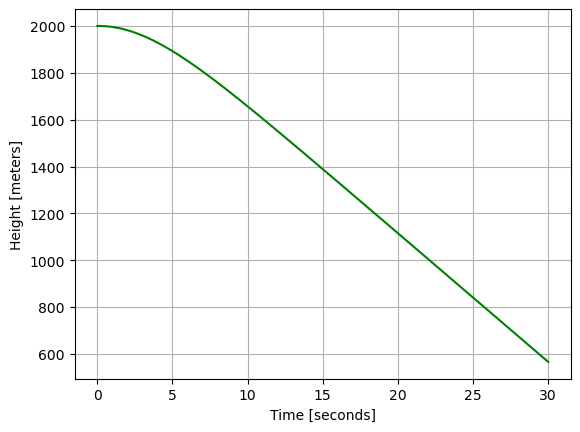

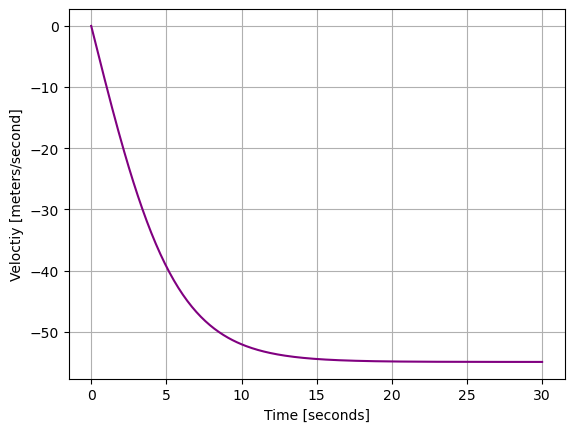

In [24]:
### ANSWER ###
# Import modules
import matplotlib.pyplot as plt

# Initialize variables
h = 2000 # initial height: m ### MODIFIED CODE
v = 0 # initial velocoty: m/s 
g = -9.81 # gravity: m/s^2
t = 0 # initial time
tmax = 30 # Falling time
dt = 0.1 # timestep ### MODIFIED CODE

# Initialize lists for storing data
height = []
velocity = []
time = []

# Append initial values to lists
height.append(h)
velocity.append(v)
time.append(t)

# Create a function to compute derivaives of velocity and height
def derivs(v,g):
    # Define some variables for the air resistance (NEW CODE)
    A = 0.4 # m^2 ### NEW CODE 
    m = 80.0 # kg ### NEW CODE
    
    # derivative of height is velocity
    dhdt = v
    
    # derivative of velocity is gravity in this example
    ### MODIFIED CODE
    dvdt = g + (-0.65 * A * v * abs(v))/m
    
    return dhdt, dvdt

# Create a time loop that will update the skydiver over time
# Use a while loop that will loop until t > tmax
while t <= tmax:
    
    # Compute derivatives for use in update equations
    dhdt, dvdt = derivs(v,g)
    
    # Update Equations
    h_new = h + dhdt*dt # new height
    
    v_new = v + dvdt*dt # new velocity
    
    # Append values to height and velocity lists
    height.append(h_new)
    velocity.append(v_new)
    
    # Update old height/velocity with new height
    h = h_new
    v = v_new
    
    # Increase time
    t += dt # t = t + dt
    
    # Update time list
    time.append(t)
    
# Plotting height/velocity vs time 
plt.figure(1)
plt.plot(time, height, color = 'green')
plt.xlabel('Time [seconds]')
plt.ylabel('Height [meters]')
plt.grid()

plt.figure(2)
plt.plot(time, velocity, color = 'purple')
plt.xlabel('Time [seconds]')
plt.ylabel('Veloctiy [meters/second]')
plt.grid()

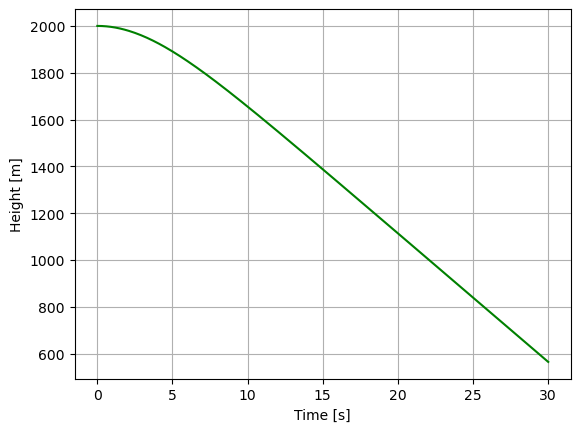

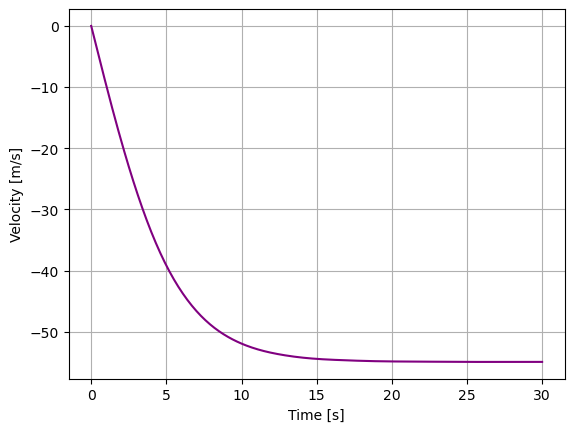

In [25]:
### ANSWER ###

# Import commands
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp # This one is new to you!

# Derivative function
def derivs(time,curr_vals):
    
    # Declare parameters
    g = -9.81 # m/s^2
    A = 0.4 # m^2 ### NEW CODE
    m = 80.0 # kg ### NEW CODE
    
    # Unpack the current values of the variables we wish to "update" from the curr_vals list
    h, v = curr_vals
    
    # Right-hand side of odes, which are used to compute the derivative
    dhdt = v
    dvdt = g + (-0.65 * A * v * abs(v))/m
    
    return dhdt, dvdt

# Declare Variables for initial conditions
h0 = 2000 # meters ### MODIFIED CODE
v0 = 0 # m/s
g = -9.81 # m/s^2
tmax = 30 # seconds ### MODIFIED CODE
dt = 0.1 # seconds ### MODIFIED CODE

# Define the time array
time = np.arange(0, tmax + dt, dt)

# Store the initial values in a list
init = [h0, v0]

# Solve the odes with solve_ivp
sol = solve_ivp(derivs, (0,tmax),init,t_eval = time)

# Unpack the results stored in the solution variable, "sol"
h = sol.y[0,:]
v = sol.y[1,:]
t = sol.t

# Plot the results we unpacked from "sol"

plt.figure(1)
plt.plot(t,h,color = 'green')
plt.xlabel('Time [s]')
plt.ylabel('Height [m]')
plt.grid()

plt.figure(2)
plt.plot(t,v, color = 'purple')
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.grid()

&#9989;&nbsp; **Question**: Do your plots of the height and velocity of the skydiver from `solve_ivp` agree with your solution when you used the update equations?

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **Question**: Based on your results, what does the terminal velocity of the skydiver appear to be?

<font size=+3>&#9998;</font> *Put your answer here.*

# Part 3 Give 'em a parachute!  (Time Permitting) 

Now, let's make a final modification to make this a little more realistic, and give the skydiver a parachute.  **Modify your `solve_ivp` code from above** to do the following:
* simulate **freefall with air resistance for heights above 1000 meters**
* **implement a parachute** once the height is less than 1000 meters.

Use your modified model to answer the following questions:
1. What parameter(s) do you need to modify in the model to approximate parachute behavior?
2. What are the specifications needed for the parachute in order to achieve a final speed of 5 m/s?  (You should be able to answer this from the derivative equations and verify with the model!)

In [31]:
#Put your solve_ivp code here


In [8]:
### ANSWER ###
# using derivative equations - dv/dt = 0
g = 9.81
m = 80
v = 5
A = g*m/0.65/v/v
print(A)

# the area should be just under 50 m^2

48.29538461538462


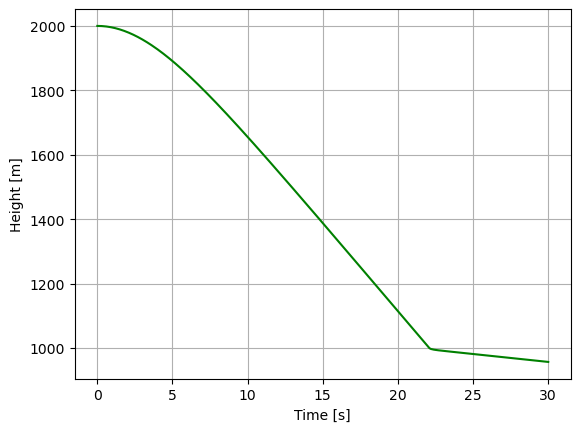

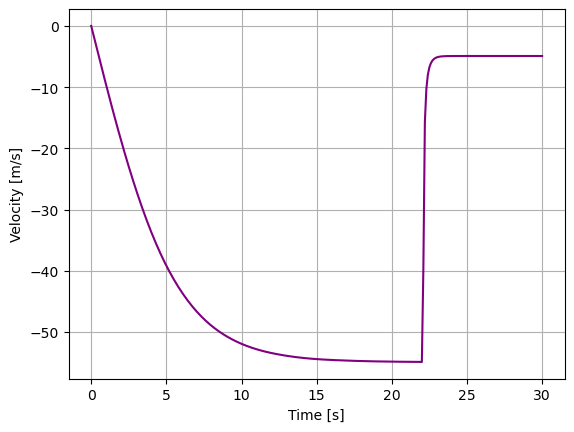

In [32]:
### ANSWER ###

# Import commands
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp # This one is new to you!

# Derivative function
def derivs(time,curr_vals):
    
    # Declare parameters
    g = -9.81 # m/s^2
    A = 0.4 # m^2 ### NEW CODE
    m = 80.0 # kg ### NEW CODE
    
    # Unpack the current values of the variables we wish to "update" from the curr_vals list
    h, v = curr_vals

    if h < 1000:
        A = 50
    
    # Right-hand side of odes, which are used to compute the derivative
    dhdt = v
    dvdt = g + (-0.65 * A * v * abs(v))/m
    
    return dhdt, dvdt

# Declare Variables for initial conditions
h0 = 2000 # meters ### MODIFIED CODE
v0 = 0 # m/s
g = -9.81 # m/s^2
tmax = 30 # seconds ### MODIFIED CODE
dt = 0.1 # seconds ### MODIFIED CODE

# Define the time array
time = np.arange(0, tmax + dt, dt)

# Store the initial values in a list
init = [h0, v0]

# Solve the odes with solve_ivp
sol = solve_ivp(derivs, (0,tmax),init,t_eval = time)

# Unpack the results stored in the solution variable, "sol"
h = sol.y[0,:]
v = sol.y[1,:]
t = sol.t

# Plot the results we unpacked from "sol"

plt.figure(1)
plt.plot(t,h,color = 'green')
plt.xlabel('Time [s]')
plt.ylabel('Height [m]')
plt.grid()

plt.figure(2)
plt.plot(t,v, color = 'purple')
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.grid()

---
### Assignment wrapup

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

In [2]:
from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://cmse.msu.edu/cmse201-ic-survey" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

### Congratulations, you're done!

Submit this assignment by uploading it to the course D2L web page.  Go to the "Pre-class assignments" folder, find the appropriate submission link, and upload it there.

See you in class!

&#169; Copyright 2025,  Michigan State University Board of Trustees